In [11]:
import pandas as pd
import os
from utils.ml_utils_v2 import EmissionsPredictionPipeline
from utils.eda_utils import EDAUtils, DataCleaningUtils
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib

In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")

In [14]:
TRAINING_DATA_PATH = os.path.join(TRAINING_DIR_PATH, "training_data_w_suffix.csv") #NOTE: update filename as needed
training_df = pd.read_csv(TRAINING_DATA_PATH)
training_df = training_df.drop(columns=["primary_id", "future_id"])
training_df.head()

,group_14_L_Industrial Energy Fuel Fraction,group_19_L_Unadjusted Land Use Transition Probability,group_43_L_Transportation Mode Fuel Fraction,group_51_L_Treatment Fraction,group_9_L_,group_49_L_Septic Sludge Compliance Fraction,group_52_L_Treatment Fraction,group_5_L_Annual Capture and Sequestration by Type,group_47_L_Regional Transportation Mode Share,group_32_L_SCOE Appliance Energy Demand Scalar,...,group_56_L_Fraction of Landfill Gas Recovered for Energy,group_33_L_SCOE Efficiency Factor for Heat Energy from Solid Biomass,group_22_L_Land Use Biomass Sequestration Factor,group_34_L_SCOE Fraction Heat Energy Demand,group_39_L_Fuel Efficiency,group_44_L_Transportation Mode Fuel Fraction,group_24_L_Livestock Manure Management Fraction,group_17_L_:math:\text{N}_2\text{O},group_6_L_Electrical Transmission Loss Fraction,emission_total
0,0.520913,0.873770,0.643369,0.426574,0.373986,0.712912,0.702289,0.205440,0.832475,0.987865,...,0.179774,0.274968,0.123492,0.326242,0.672534,0.345412,0.538583,0.261322,0.878380,12722.540096
1,0.317885,0.813716,0.705113,0.158652,0.896463,0.531140,0.752524,0.453622,0.327739,0.714720,...,0.923214,0.176500,0.259777,0.783529,0.339051,0.590931,0.632658,0.599761,0.175245,10789.164729
2,0.068678,0.463367,0.609188,0.205757,0.698922,0.666624,0.121025,0.023411,0.252646,0.682092,...,0.120159,0.118951,0.954133,0.781652,0.482346,0.874385,0.973150,0.692794,0.653164,12424.639204
3,0.791881,0.230188,0.597047,0.070456,0.113597,0.886711,0.128951,0.676908,0.809182,0.611600,...,0.565971,0.580326,0.859357,0.975148,0.603157,0.077945,0.778128,0.340814,0.096409,11043.568078
4,0.352845,0.464106,0.168156,0.980789,0.628671,0.437718,0.330971,0.765432,0.305613,0.531167,...,0.074636,0.804465,0.118725,0.430977,0.240433,0.366491,0.057006,0.269641,0.831340,12273.934298


## EDA

In [15]:
edau = EDAUtils()

In [16]:
target_col = "emission_total"

In [17]:
lhs_group_cols = training_df.drop(columns=[target_col]).columns.tolist()

In [18]:
training_df[target_col].describe()

count      947.000000
mean     12313.102123
std        901.894913
min       9818.293201
25%      11689.663307
50%      12247.683936
75%      12846.943565
max      15675.627979
Name: emission_total, dtype: float64

In [19]:
for col in training_df.columns:
    nans = training_df[col].isna().sum()
    neg_infs = (training_df[col] == -np.inf).sum()
    pos_infs = (training_df[col] == np.inf).sum()
    if nans > 0 or neg_infs > 0 or pos_infs > 0:
        print(f"WARNING: Column '{col}' has {nans} NaNs, {neg_infs} -inf, {pos_infs} inf values.")

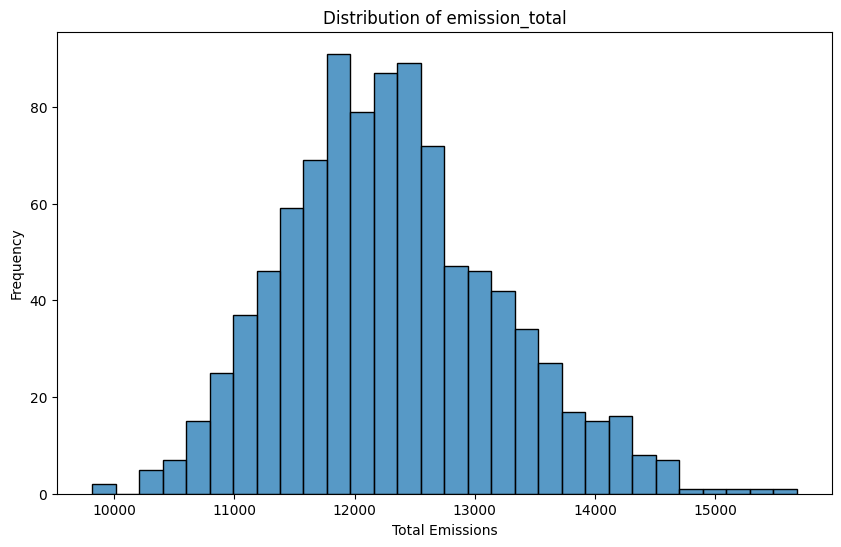

In [20]:
edau.plot_emissions_histogram(training_df, "emission_total", title="Distribution of emission_total", kde=False)

In [21]:
edau.get_target_var_corr(training_df, "emission_total", exclude_cols=target_col)


Correlation with target variable 'emission_total' (threshold: 0.1):
--------------------------------------------------
group_34_L_SCOE Fraction Heat Energy Demand  : 0.4442
group_31_L_SCOE Heat Energy Demand Scalar : 0.3347
group_4_L_Crop Yield Factor    : 0.2621
group_39_L_Fuel Efficiency     : 0.2377
group_27_L_:math:\text{CH}_4 Enteric Fermentation Emission Factor : 0.2363
group_29_L_Fraction Eating Red Meat : 0.2332
group_37_L_Transportation Demand Scalar : 0.2124
group_42_L_Transportation Mode Fuel Fraction  : 0.1875
group_14_L_Industrial Energy Fuel Fraction  : 0.1434
group_19_L_Unadjusted Land Use Transition Probability : 0.1385



In [22]:
# Outlier inspection
outliers = edau.find_outlier_columns(training_df, method="iqr", factor=1.5)
print("Outlier percentages:", outliers)
outliers = edau.find_outlier_columns(training_df, method="zscore", z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {'emission_total': 1.16}
Outlier percentages: {'emission_total': 0.32}


## Data Cleaning

In [23]:
dcu = DataCleaningUtils()

In [24]:
training_df.shape

(947, 62)

In [25]:
# # Check those -inf values in technical_cost
# technical_cost_neg_inf = training_df[training_df["technical_cost"] == -np.inf]
# technical_cost_neg_inf

In [26]:
# # filter out -inf values in technical_cost
# training_df = training_df[training_df["technical_cost"] != -np.inf]
# training_df.shape

In [27]:
training_df_cleaned = dcu.remove_outliers(training_df, method="zscore", z_thresh=3.0)
print("Shape before removing outliers:", training_df.shape)
print("Shape after removing outliers:", training_df_cleaned.shape)

Shape before removing outliers: (947, 62)
Shape after removing outliers: (944, 62)


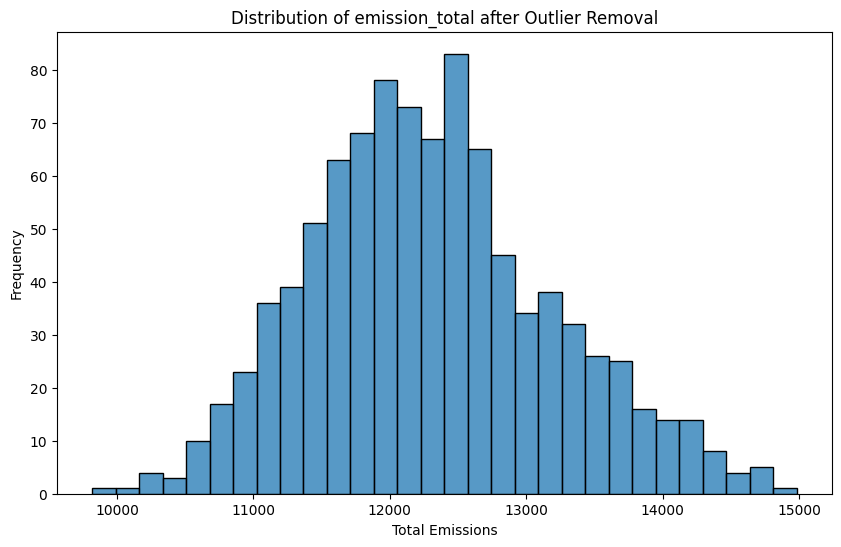

In [30]:
edau.plot_emissions_histogram(training_df_cleaned,
                              column="emission_total",
                              title="Distribution of emission_total after Outlier Removal",
                              kde=False)

In [31]:
outliers = edau.find_outlier_columns(training_df_cleaned, method="zscore", z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {'emission_total': 0.11}


In [33]:
edau.get_target_var_corr(training_df, "emission_total", exclude_cols="emission_total")


Correlation with target variable 'emission_total' (threshold: 0.1):
--------------------------------------------------
group_34_L_SCOE Fraction Heat Energy Demand  : 0.4442
group_31_L_SCOE Heat Energy Demand Scalar : 0.3347
group_4_L_Crop Yield Factor    : 0.2621
group_39_L_Fuel Efficiency     : 0.2377
group_27_L_:math:\text{CH}_4 Enteric Fermentation Emission Factor : 0.2363
group_29_L_Fraction Eating Red Meat : 0.2332
group_37_L_Transportation Demand Scalar : 0.2124
group_42_L_Transportation Mode Fuel Fraction  : 0.1875
group_14_L_Industrial Energy Fuel Fraction  : 0.1434
group_19_L_Unadjusted Land Use Transition Probability : 0.1385



In [35]:
# training_df_cleaned[target_cols].describe()

In [36]:
# sns.pairplot(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

In [37]:
# edau.plot_correlation_matrix(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

## ML

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XGB hyperparameters: {'subsample': 0.6, 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 1.0}
XGB             → MAE: 467.7666, RMSE: 574.4455, R²: 0.5892, SMAPE: 3.8%
MeanBaseline    → MAE: 703.2205, RMSE: 896.6835, R²: -0.0009, SMAPE: 5.7%
MedianBaseline  → MAE: 700.0269, RMSE: 896.9713, R²: -0.0015, SMAPE: 5.7%
RandomForest    → MAE: 543.6309, RMSE: 674.7599, R²: 0.4333, SMAPE: 4.4%
ElasticNet      → MAE: 480.7544, RMSE: 607.0575, R²: 0.5413, SMAPE: 3.9%


/opt/miniconda3/envs/ssp_uganda_env/lib/python3.11/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/miniconda3/envs/ssp_uganda_env/lib/python3.11/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/miniconda3/envs/ssp_uganda_env/lib/python3.11/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_



=== CV Results for XGB ===
MAE: 473.1424 ± 19.6882
R2: 0.5398 ± 0.0374
RMSE: 597.4018 ± 15.8496

=== CV Results for MeanBaseline ===
MAE: 707.5474 ± 25.9052
R2: -0.0018 ± 0.0022
RMSE: 882.9244 ± 26.3099

=== CV Results for MedianBaseline ===
MAE: 706.7501 ± 24.4558
R2: -0.0071 ± 0.0054
RMSE: 885.2467 ± 25.1551

=== CV Results for RandomForest ===
MAE: 535.9417 ± 13.4068
R2: 0.4231 ± 0.0328
RMSE: 669.3433 ± 13.5948

=== CV Results for ElasticNet ===
MAE: 479.5001 ± 18.0095
R2: 0.5306 ± 0.0167
RMSE: 604.0141 ± 10.0183


/opt/miniconda3/envs/ssp_uganda_env/lib/python3.11/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/miniconda3/envs/ssp_uganda_env/lib/python3.11/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/miniconda3/envs/ssp_uganda_env/lib/python3.11/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/miniconda3/envs/ssp_uganda_env/lib/python3.11/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/miniconda3/envs/ssp_uganda_env/lib/python3.11/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/miniconda3/envs/ssp_uganda_env/lib/python3.11/site-package

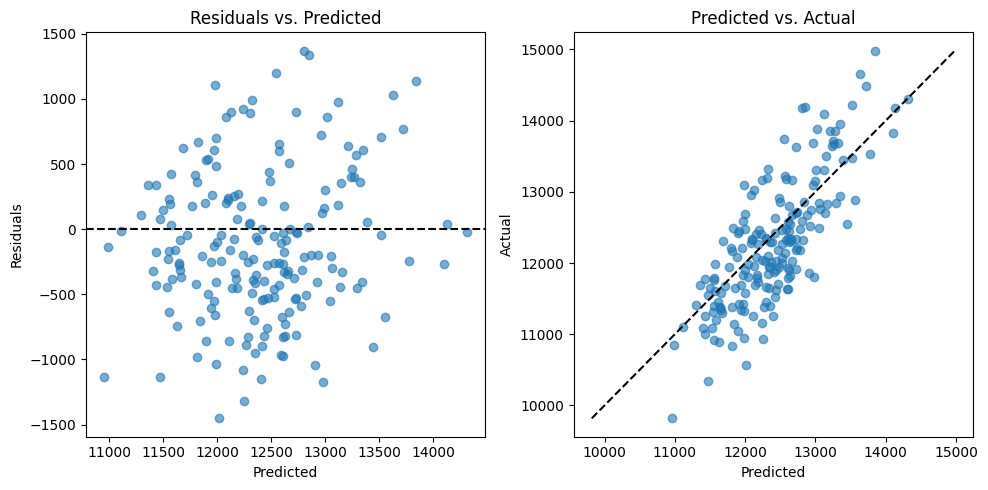

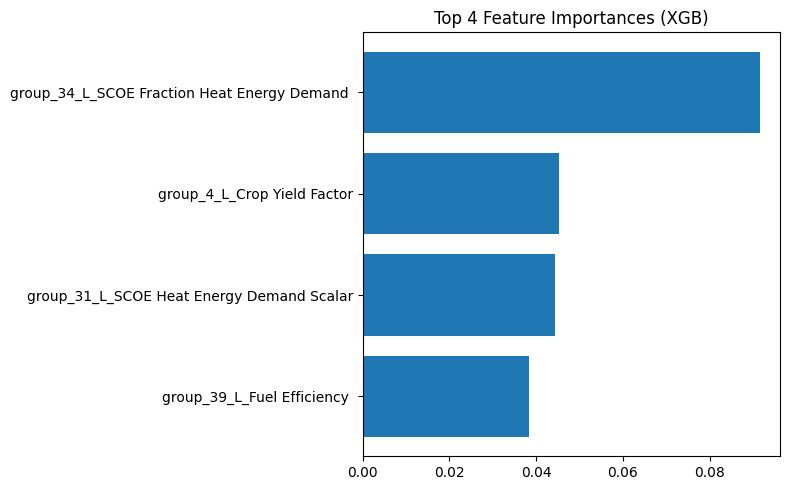

In [43]:
epp = EmissionsPredictionPipeline(df=training_df_cleaned, target="emission_total", test_size=0.2)
epp.run(tune=True, log_transform=False, create_plots=True)

## Save the trained and tuned model and use it to predict new data

In [44]:
training_df_cleaned.head()

,group_14_L_Industrial Energy Fuel Fraction,group_19_L_Unadjusted Land Use Transition Probability,group_43_L_Transportation Mode Fuel Fraction,group_51_L_Treatment Fraction,group_9_L_,group_49_L_Septic Sludge Compliance Fraction,group_52_L_Treatment Fraction,group_5_L_Annual Capture and Sequestration by Type,group_47_L_Regional Transportation Mode Share,group_32_L_SCOE Appliance Energy Demand Scalar,...,group_56_L_Fraction of Landfill Gas Recovered for Energy,group_33_L_SCOE Efficiency Factor for Heat Energy from Solid Biomass,group_22_L_Land Use Biomass Sequestration Factor,group_34_L_SCOE Fraction Heat Energy Demand,group_39_L_Fuel Efficiency,group_44_L_Transportation Mode Fuel Fraction,group_24_L_Livestock Manure Management Fraction,group_17_L_:math:\text{N}_2\text{O},group_6_L_Electrical Transmission Loss Fraction,emission_total
0,0.520913,0.873770,0.643369,0.426574,0.373986,0.712912,0.702289,0.205440,0.832475,0.987865,...,0.179774,0.274968,0.123492,0.326242,0.672534,0.345412,0.538583,0.261322,0.878380,12722.540096
1,0.317885,0.813716,0.705113,0.158652,0.896463,0.531140,0.752524,0.453622,0.327739,0.714720,...,0.923214,0.176500,0.259777,0.783529,0.339051,0.590931,0.632658,0.599761,0.175245,10789.164729
2,0.068678,0.463367,0.609188,0.205757,0.698922,0.666624,0.121025,0.023411,0.252646,0.682092,...,0.120159,0.118951,0.954133,0.781652,0.482346,0.874385,0.973150,0.692794,0.653164,12424.639204
3,0.791881,0.230188,0.597047,0.070456,0.113597,0.886711,0.128951,0.676908,0.809182,0.611600,...,0.565971,0.580326,0.859357,0.975148,0.603157,0.077945,0.778128,0.340814,0.096409,11043.568078
4,0.352845,0.464106,0.168156,0.980789,0.628671,0.437718,0.330971,0.765432,0.305613,0.531167,...,0.074636,0.804465,0.118725,0.430977,0.240433,0.366491,0.057006,0.269641,0.831340,12273.934298


In [45]:
# Get a single row from training_df_cleaned for prediction
single_row = training_df_cleaned.iloc[0].drop(columns="emission_total")
single_row = single_row.to_frame().T  # Convert to DataFrame
single_row

,group_14_L_Industrial Energy Fuel Fraction,group_19_L_Unadjusted Land Use Transition Probability,group_43_L_Transportation Mode Fuel Fraction,group_51_L_Treatment Fraction,group_9_L_,group_49_L_Septic Sludge Compliance Fraction,group_52_L_Treatment Fraction,group_5_L_Annual Capture and Sequestration by Type,group_47_L_Regional Transportation Mode Share,group_32_L_SCOE Appliance Energy Demand Scalar,...,group_56_L_Fraction of Landfill Gas Recovered for Energy,group_33_L_SCOE Efficiency Factor for Heat Energy from Solid Biomass,group_22_L_Land Use Biomass Sequestration Factor,group_34_L_SCOE Fraction Heat Energy Demand,group_39_L_Fuel Efficiency,group_44_L_Transportation Mode Fuel Fraction,group_24_L_Livestock Manure Management Fraction,group_17_L_:math:\text{N}_2\text{O},group_6_L_Electrical Transmission Loss Fraction,emission_total
0,0.520913,0.87377,0.643369,0.426574,0.373986,0.712912,0.702289,0.20544,0.832475,0.987865,...,0.179774,0.274968,0.123492,0.326242,0.672534,0.345412,0.538583,0.261322,0.87838,12722.540096


In [48]:
# Predict using the trained model
predictions = epp.predict(single_row, model_name="XGB")
print("Predictions for single row:")
print(predictions)
print("Original values:")
print(training_df_cleaned.iloc[0][["emission_total"]])

Predictions for single row:
[12925.406]
Original values:
emission_total    12722.540096
Name: 0, dtype: float64


In [55]:
import os, json, joblib, platform, sys
import numpy as np
import xgboost as xgb
from datetime import datetime

def save_xgb_artifacts(epp, out_dir, filename_stub, overwrite=True):
    os.makedirs(out_dir, exist_ok=True)

    # The class stores the raw XGBRegressor under "XGB"
    xgb_model = epp.pipelines["XGB"]
    feature_names = list(epp.X_train.columns)

    # A) Save Python object for quick same-env reload
    pkl_path = os.path.join(out_dir, f"{filename_stub}.pkl")
    if os.path.exists(pkl_path) and not overwrite:
        raise FileExistsError(f"Exists: {pkl_path}")
    joblib.dump(xgb_model, pkl_path)

    # B) Save XGBoost native model (portable across Python/sklearn versions)
    json_path = os.path.join(out_dir, f"{filename_stub}.json")
    xgb_model.save_model(json_path)

    # C) Save metadata snapshot for reproducibility
    meta = {
        "saved_at": datetime.utcnow().isoformat() + "Z",
        "python": sys.version,
        "platform": platform.platform(),
        "packages": {
            "xgboost": xgb.__version__,
            "numpy": np.__version__,
        },
        "target": epp.target,
        "log_transform": epp._log_transform,
        "feature_names": feature_names,
        "best_iteration": getattr(xgb_model, "best_iteration", None),
        "best_score": getattr(xgb_model, "best_score", None),
        "params": xgb_model.get_xgb_params(),
    }
    with open(os.path.join(out_dir, f"{filename_stub}.meta.json"), "w") as f:
        json.dump(meta, f, indent=2)

    return {"pkl": pkl_path, "json": json_path}


In [56]:
ARTIFACTS_DIR = os.path.join(SCRIPT_DIR_PATH, "trained_models")
save_xgb_artifacts(
    epp, ARTIFACTS_DIR,
    filename_stub="xgb_w_suffix",
    overwrite=True
)

{'pkl': '/Users/tony/Documents/sisepuede_modeling/ssp_uganda_data/new_metamodel/surrogate_model/trained_models/xgb_w_suffix.pkl',
 'json': '/Users/tony/Documents/sisepuede_modeling/ssp_uganda_data/new_metamodel/surrogate_model/trained_models/xgb_w_suffix.json'}

In [58]:
import joblib
model = joblib.load(os.path.join(ARTIFACTS_DIR, "xgb_w_suffix.pkl"))
y_hat = model.predict(training_df_cleaned[epp.X_train.columns])
# respect early stopping if present:
if hasattr(model, "best_iteration") and model.best_iteration is not None:
    try:
        y_hat = model.predict(training_df_cleaned[epp.X_train.columns],
                              iteration_range=(0, model.best_iteration + 1))
    except TypeError:
        y_hat = model.predict(training_df_cleaned[epp.X_train.columns],
                              ntree_limit=model.best_iteration + 1)
if epp._log_transform:
    y_hat = np.expm1(y_hat)


In [60]:
[col for col in training_df_cleaned.columns if "_X_" in col]

['group_60_X_exports', 'group_61_X_cost_enfu_fuel']